# EDA Decission Tree

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
import pickle

## Definición del problema

>### Prediciendo la diabetes
>Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y enales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

## Recopilación de datos

In [27]:
df = pd.read_csv('/workspaces/adamcn10-intro-ml/data/raw/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Análisis Descriptivo

In [28]:
df.shape

(768, 9)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [31]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

## Limpieza de datos

### Eliminar Duplicados

In [32]:
df.duplicated().sum()

np.int64(0)

### Eliminar información irrelevante

>A priori no vemos ningun dato irrelevante

## Análisis de Variables

### Análisis de Variables Univariable

<function matplotlib.pyplot.show(close=None, block=None)>

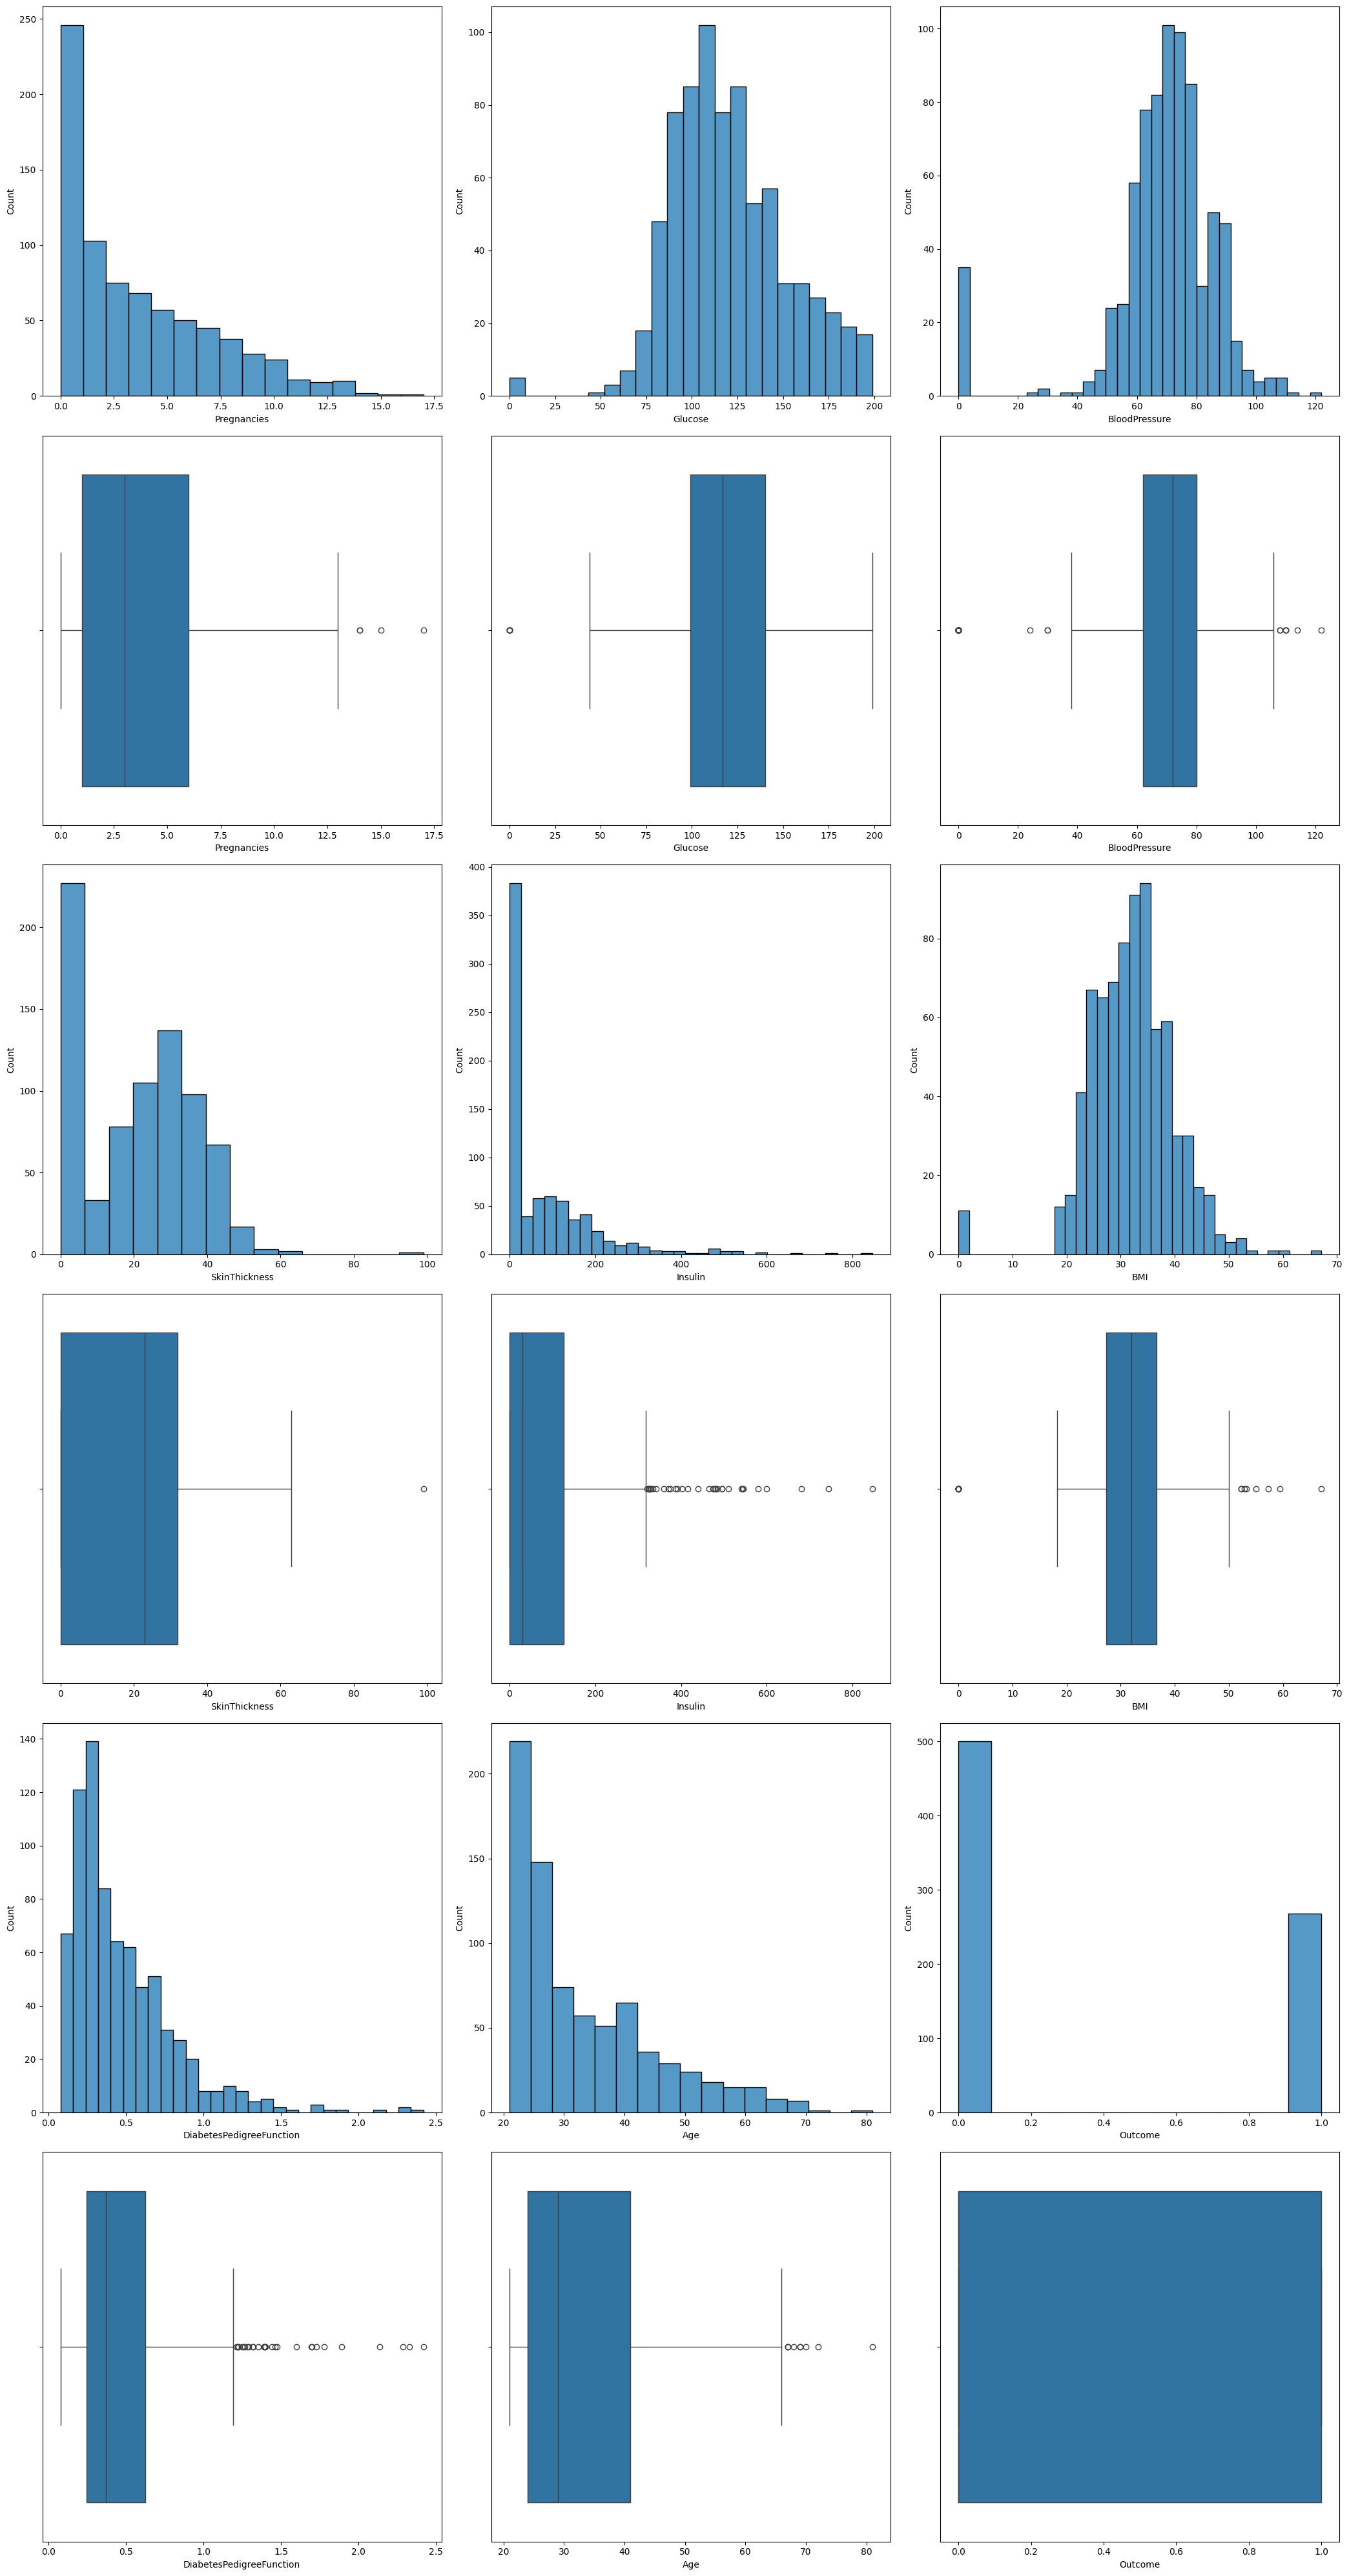

In [33]:
fig, axis = plt.subplots(6, 3, figsize=(21, 40))

sns.histplot(ax=axis[0, 0], data=df, x="Pregnancies")
sns.boxplot(ax=axis[1, 0], data=df, x="Pregnancies")
sns.histplot(ax=axis[0, 1], data=df, x="Glucose")
sns.boxplot(ax=axis[1, 1], data=df, x="Glucose")
sns.histplot(ax=axis[0, 2], data=df, x="BloodPressure")
sns.boxplot(ax=axis[1, 2], data=df, x="BloodPressure")
sns.histplot(ax=axis[2, 0], data=df, x="SkinThickness")
sns.boxplot(ax=axis[3, 0], data=df, x="SkinThickness")
sns.histplot(ax=axis[2, 1], data=df, x="Insulin")
sns.boxplot(ax=axis[3, 1], data=df, x="Insulin")
sns.histplot(ax=axis[2, 2], data=df, x="BMI")
sns.boxplot(ax=axis[3, 2], data=df, x="BMI")
sns.histplot(ax=axis[4, 0], data=df, x="DiabetesPedigreeFunction")
sns.boxplot(ax=axis[5, 0], data=df, x="DiabetesPedigreeFunction")
sns.histplot(ax=axis[4, 1], data=df, x="Age")
sns.boxplot(ax=axis[5, 1], data=df, x="Age")
sns.histplot(ax=axis[4, 2], data=df, x="Outcome")
sns.boxplot(ax=axis[5, 2], data=df, x="Outcome")

plt.tight_layout()
plt.show

>Vemos como se distribuyen y las formas que tienen los datos

### Análisis de Variables Multivariable

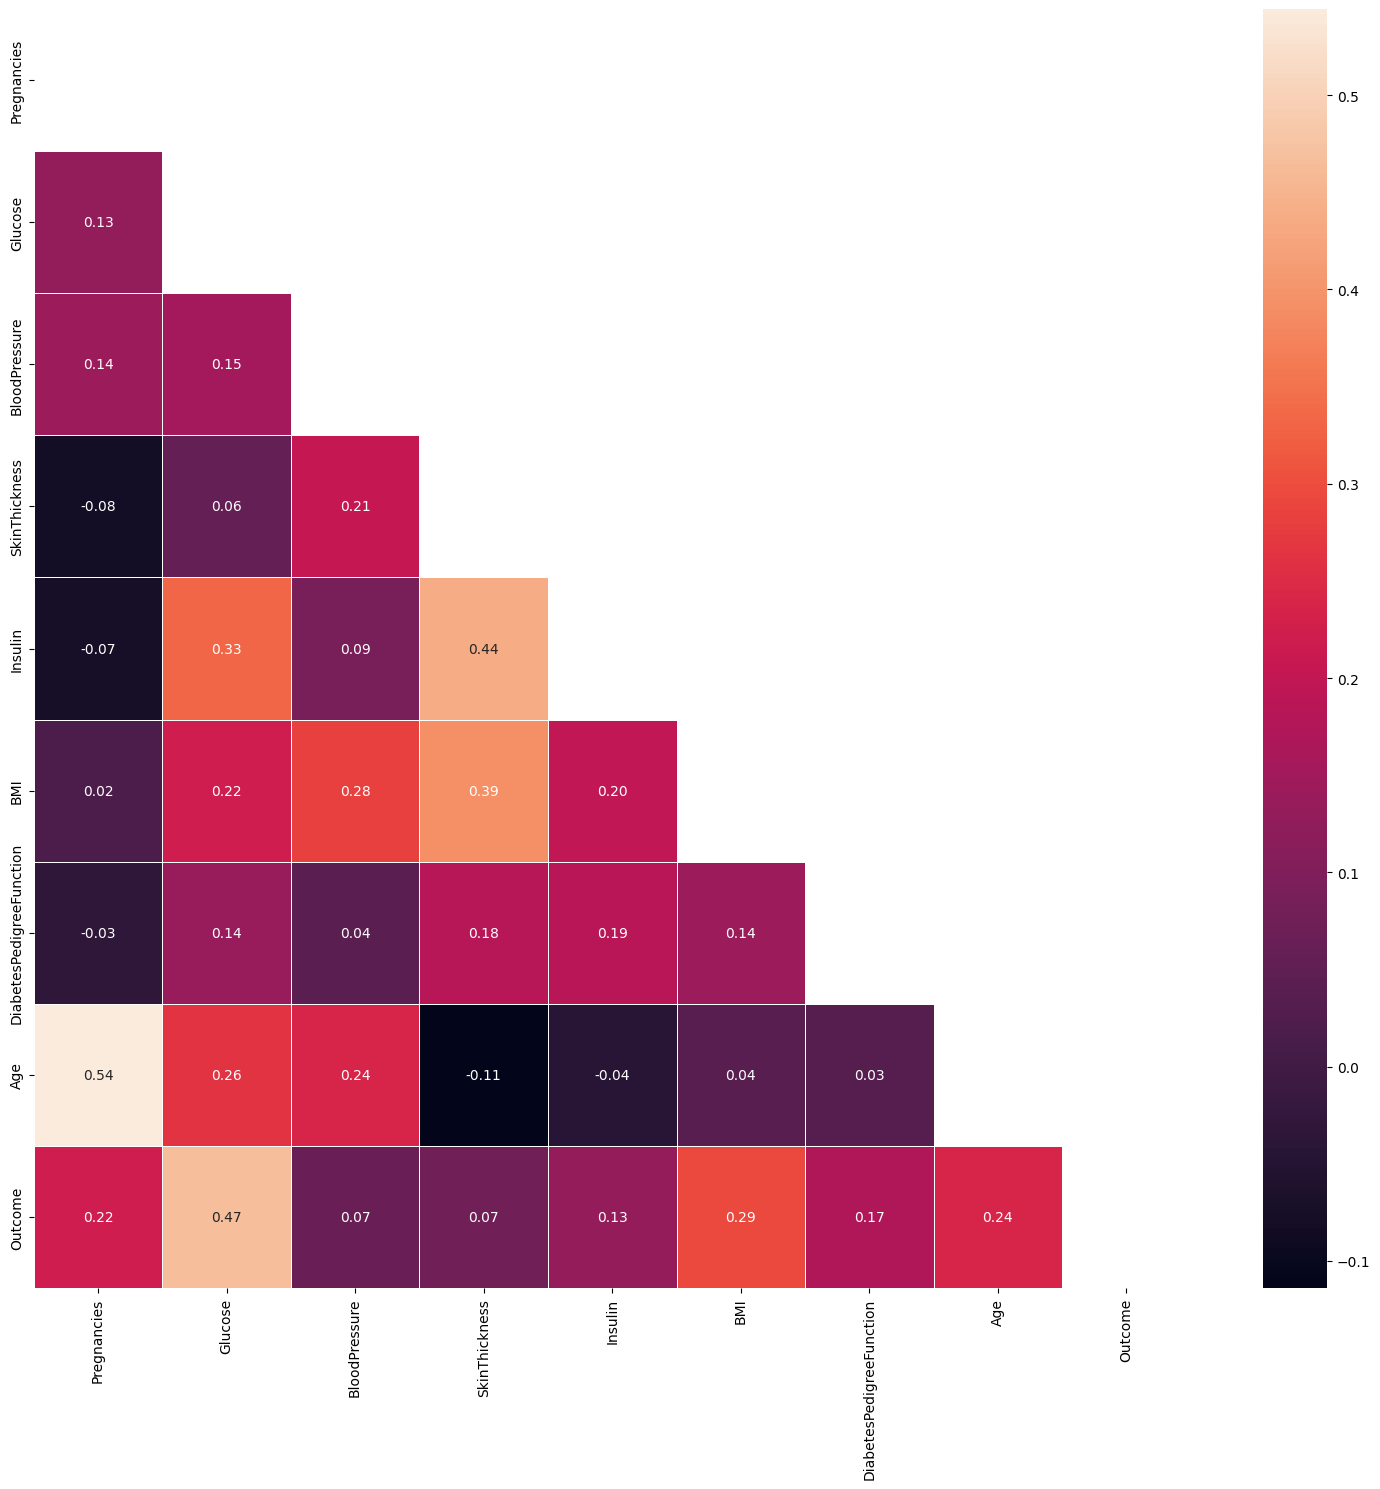

In [34]:
corr = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 15))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

>Las correlaciones que vemos con la variable objetivo son principalmente la glucosa y de manera secundaria el BMI, la Edad y los Embarazos, en ese orden

## Ingeniería de Características

### Outliers

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


<function matplotlib.pyplot.show(close=None, block=None)>

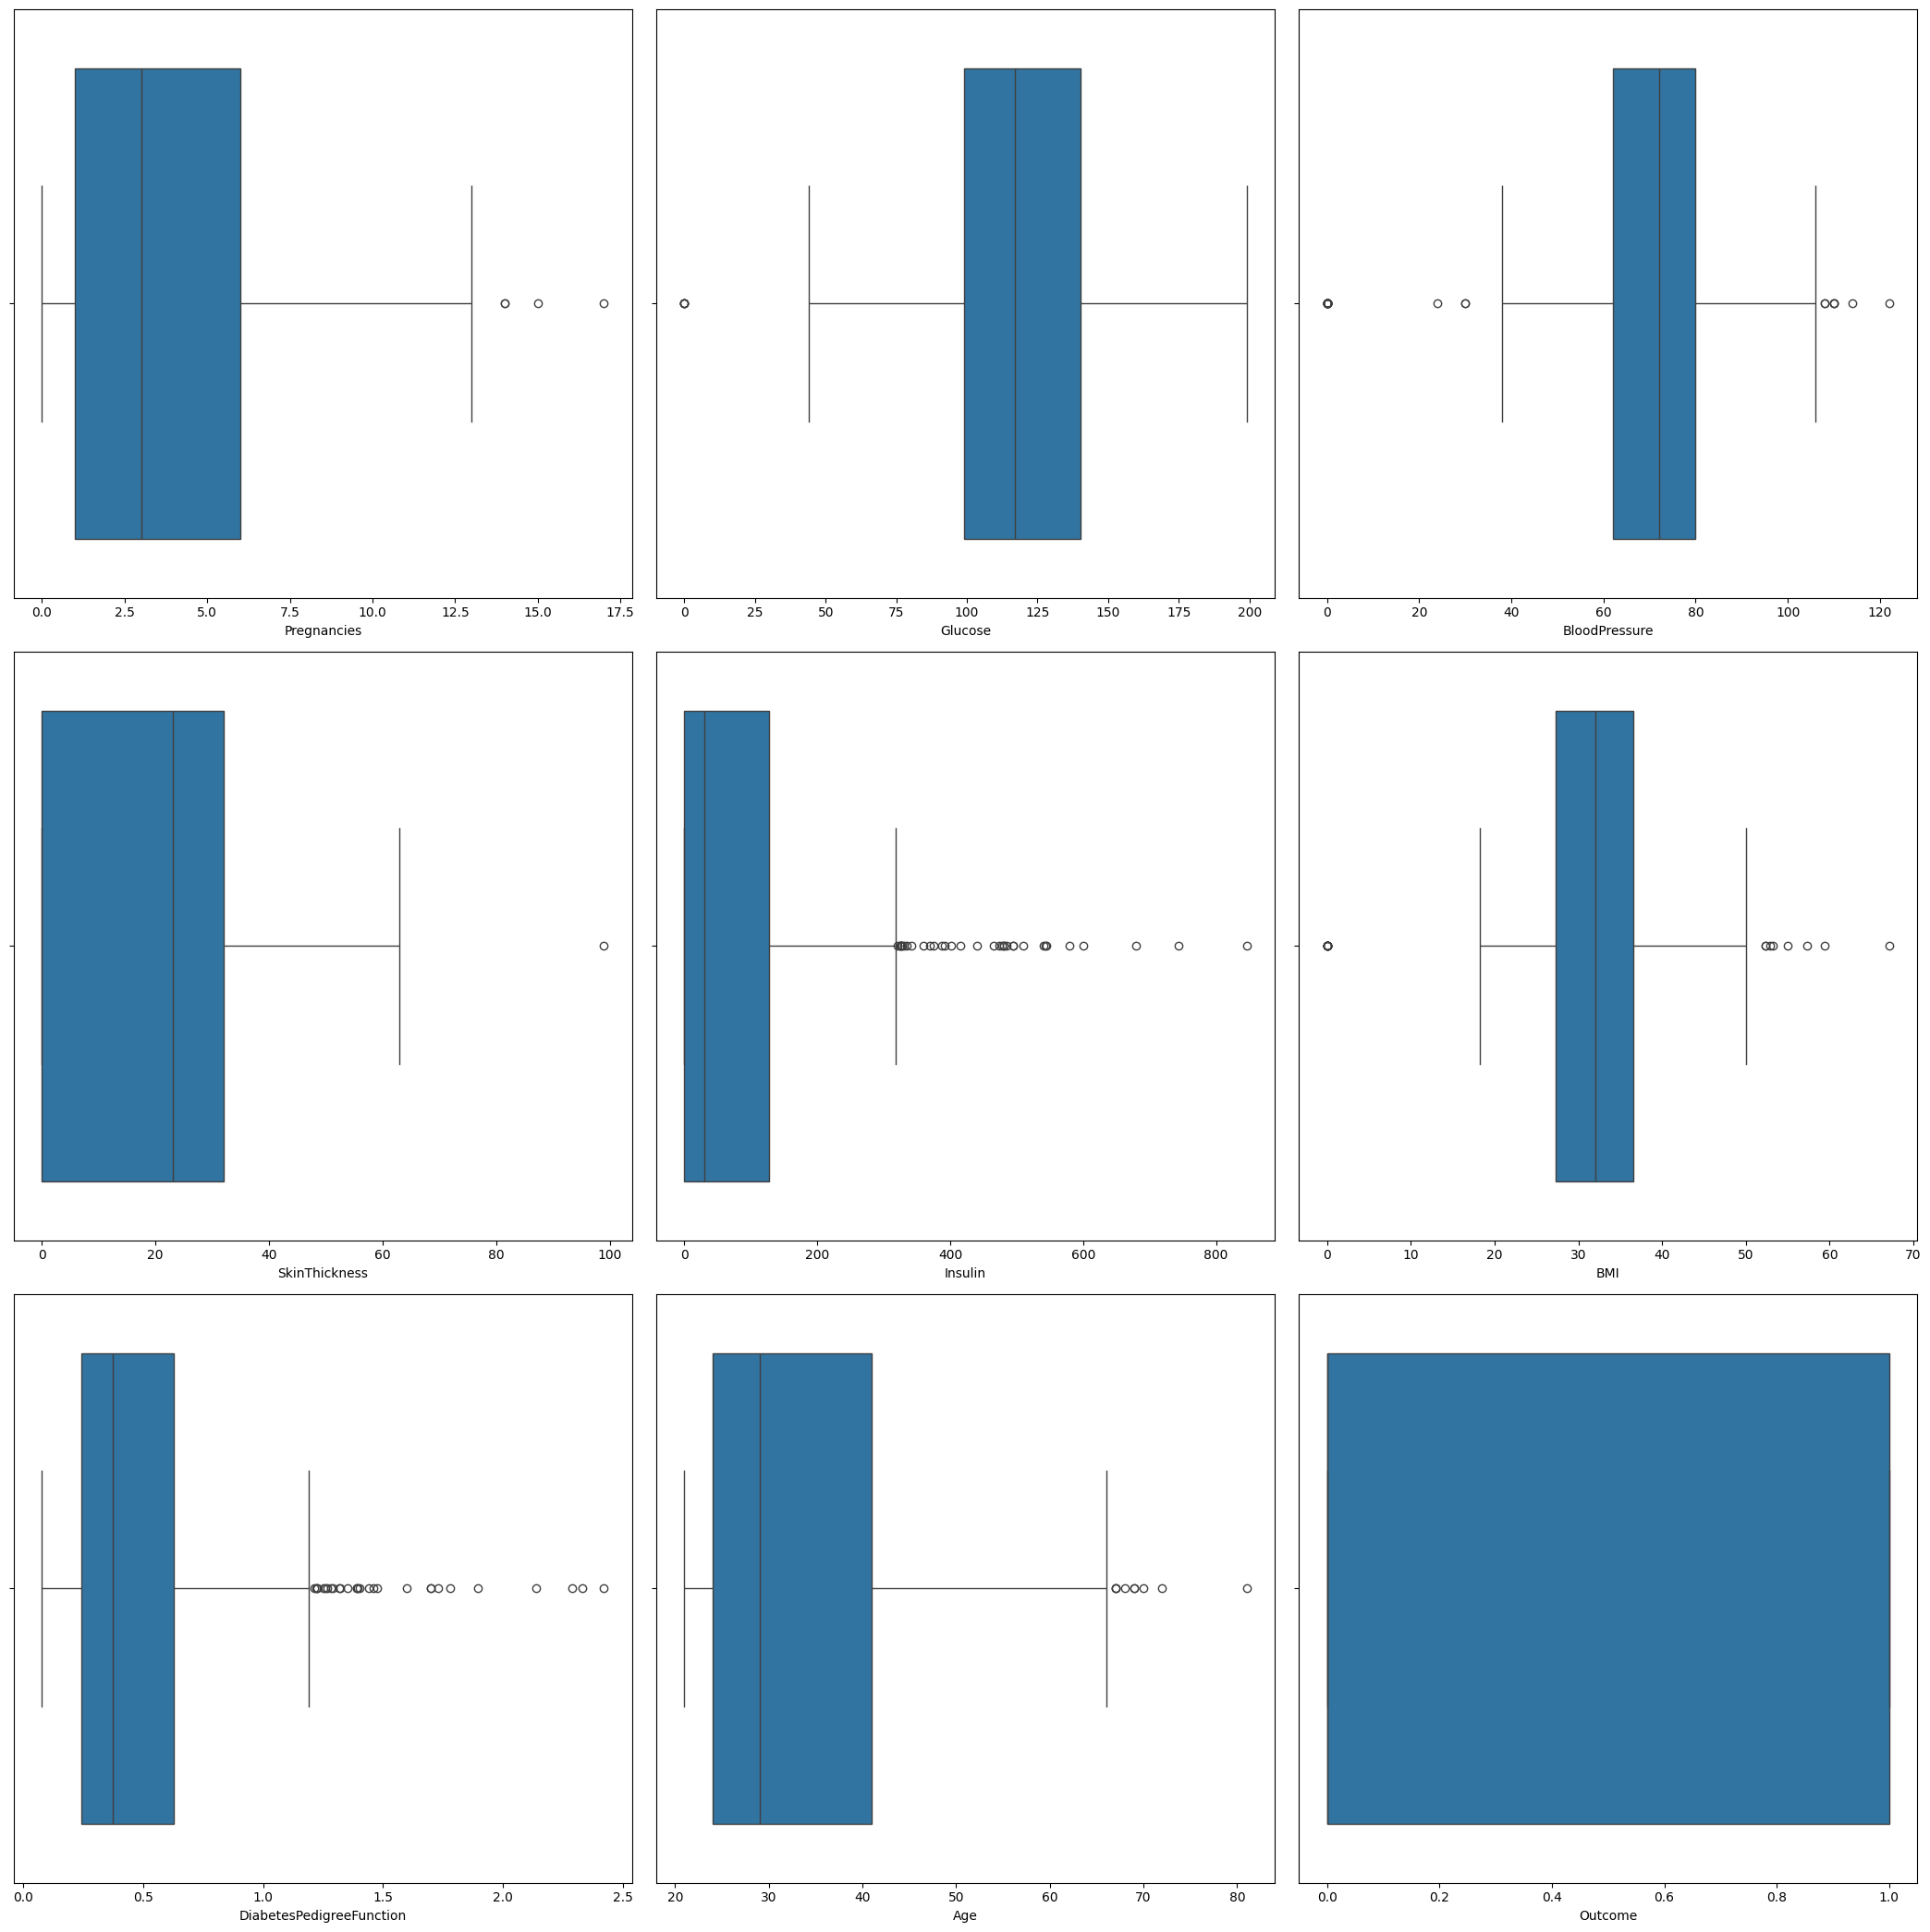

In [36]:
fig, axis = plt.subplots(3, 3, figsize=(21, 21))

sns.boxplot(ax=axis[0, 0], data=df, x="Pregnancies")
sns.boxplot(ax=axis[0, 1], data=df, x="Glucose")
sns.boxplot(ax=axis[0, 2], data=df, x="BloodPressure")
sns.boxplot(ax=axis[1, 0], data=df, x="SkinThickness")
sns.boxplot(ax=axis[1, 1], data=df, x="Insulin")
sns.boxplot(ax=axis[1, 2], data=df, x="BMI")
sns.boxplot(ax=axis[2, 0], data=df, x="DiabetesPedigreeFunction")
sns.boxplot(ax=axis[2, 1], data=df, x="Age")
sns.boxplot(ax=axis[2, 2], data=df, x="Outcome")

plt.tight_layout()
plt.show

>Vemos Outliers en datos como 'Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedifreeFunction' y 'Age'

>Pero 'Glucose' se quedará sin outliers al eliminar los 0 y 'BMI' y 'BloodPressure' perderán sus outliers más alejados con el mismo proceso.

### Faltantes

In [37]:
df.isnull().sum() / df.shape[0]

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [38]:
df.isnull().sum().sort_values(ascending=False)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

>Hay categorías donde no debería poder haber 0, consideraremos todo esto como valores nules y lo volveremos a analizar

In [39]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 
                                                                          'BloodPressure', 
                                                                          'SkinThickness', 
                                                                          'Insulin', 
                                                                          'BMI']].replace(0, np.nan)

In [40]:
df.isnull().sum() / df.shape[0]

Pregnancies                 0.000000
Glucose                     0.006510
BloodPressure               0.045573
SkinThickness               0.295573
Insulin                     0.486979
BMI                         0.014323
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

In [41]:
df.isnull().sum().sort_values(ascending=False)

Insulin                     374
SkinThickness               227
BloodPressure                35
BMI                          11
Glucose                       5
Pregnancies                   0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>Dadas esta cantidad de valores nulos vamos a llevar a cabo 3 posibles soluciones, estas son:
>- Eliminar filas con valor nulo (a partir de ahora df_nonull)
>- Reemplazar por la moda (a partir de ahora df_most_frequent)
>- Aplicar KNN Imputer (a partir de ahora df_knn)

In [42]:
df_nonull = df.dropna()
df_nonull.shape


(392, 9)

In [43]:
df_most_frequent = df

imputer = SimpleImputer(strategy='most_frequent')

columns_to_impute = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']
df_most_frequent[columns_to_impute] = imputer.fit_transform(df_most_frequent[columns_to_impute])

df_most_frequent.shape

(768, 9)

In [44]:
df_knn = df

knn_imputer = KNNImputer(n_neighbors=5)

columns_to_impute = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']

df_knn[columns_to_impute] = knn_imputer.fit_transform(df_knn[columns_to_impute])

df_knn.shape

(768, 9)

### Inferencia de nuevas características

>No veo nuevas caracteristicas que se deban generar.

## Split

>Hacemos el split con las tres formas que hemos tenido de solucionar los valores nulos

In [45]:
X = df_nonull.drop("Outcome", axis=1)
y = df_nonull["Outcome"]

X_train_nonull, X_test_nonull, y_train_nonull, y_test_nonull = train_test_split(X, y, 
                                                                                test_size=0.2, 
                                                                                random_state=25)

In [46]:
X = df_most_frequent.drop("Outcome", axis=1)
y = df_most_frequent["Outcome"]

X_train_most_frequent, X_test_most_frequent, y_train_most_frequent, y_test_most_frequent = train_test_split(X, 
                                                                                                            y,
                                                                                                            test_size=0.2,
                                                                                                            random_state=25)

In [47]:
X = df_knn.drop("Outcome", axis=1)
y = df_knn["Outcome"]

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X,
                                                                    y,
                                                                    test_size=0.2,
                                                                    random_state=25)

## Encoding & Scaling

### Encoding

>No hace falta encoding ya que todas las variables son numéricas

### Scaling

>No hace falta escalado porque aplicaremos arboles de decisión y a estos no les afecta que los datos esten en diferentes escalas

## Guardado de Datos

>Guardamos los datasets spliteados de los 3 tipos diferentes y los Imputers

In [48]:
with open('/workspaces/adamcn10-intro-ml/models/decision-tree-simple-imputer.pkl', 'wb') as file:
    pickle.dump(imputer, file)  

with open('/workspaces/adamcn10-intro-ml/models/decision-tree-knn-imputer.pkl', 'wb') as file:
    pickle.dump(knn_imputer, file)  

with open('/workspaces/adamcn10-intro-ml/models/decision-tree-knn-imputer.pkl', 'wb') as file:
    pickle.dump(knn_imputer, file)  

In [49]:
with open('/workspaces/adamcn10-intro-ml/data/processed/decision-tree-df-nonull.pkl', 'wb') as file:
    pickle.dump(df_nonull, file)  

with open('/workspaces/adamcn10-intro-ml/data/processed/decision-tree-df-most-frequent.pkl', 'wb') as file:
    pickle.dump(df_most_frequent, file)  

with open('/workspaces/adamcn10-intro-ml/data/processed/decision-tree-df-knn.pkl', 'wb') as file:
    pickle.dump(df_knn, file)  

In [50]:
X_train_nonull.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-train-nonull.csv')
X_test_nonull.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-test-nonull.csv')
y_train_nonull.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-train-nonull.csv')
y_test_nonull.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-test-nonull.csv')

In [51]:
X_train_most_frequent.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-train-most-frequent.csv')
X_test_most_frequent.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-test-most-frequent.csv')
y_train_most_frequent.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-train-most-frequent.csv')
y_test_most_frequent.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-test-most-frequent.csv')

In [52]:
X_train_knn.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-train-knn.csv')
X_test_knn.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-test-knn.csv')
y_train_knn.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-train-knn.csv')
y_test_knn.to_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-test-knn.csv')